<a href="https://colab.research.google.com/github/Symphoen1x/LearnAI-NLP/blob/main/NLP/tf_idf_tutorial_nlp_codebasics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<h2 align='center'>NLP Tutorial - Text Representation: TF-IDF</h2>

# Sumber belajar
* https://medium.com/analytics-vidhya/magic-of-tf-idf-202649d39c2f

# Note
1. Kurang bagian memahami code yang ada pembutian mtk. cukup dipahami tidak perlu dipraktikan karena cukup sudah buat dokumentasi. lalu coba,
2. building from scratch dari rumus dokumentasi tersebut dengan modal: python + pandas + numpy maybe

# QNA sementara
2. Tujuan TF-Idf! versi dicoding!
3. kenapa idf dihitung dengan logaritma?
https://chatgpt.com/c/66dbfcdb-b664-8009-b271-55f35c9abffb
4. kenapa TF-IDF dicari dengan mengalikan TF(yang berfokus memberikan bobot lebih tinggi pada kata-kata yang sering muncul dan dianggap lebih penting dalam konteks dokumen tersebut)   *  IDF(yg berfokus pada Kata-kata yang muncul lebih sedikit dalam dokumen dianggap memiliki informasi lebih spesifik atau unik dan mendapatkan bobot yang lebih tinggi melalui IDF)?
https://chatgpt.com/c/66dbfcdb-b664-8009-b271-55f35c9abffb
5. Katanya si TF-IDF adalah metode untuk menangani issue si BOW dan BON? dari sisi mananya?
https://chatgpt.com/c/66dbfcdb-b664-8009-b271-55f35c9abffb
6. pada saat kondisi (data/dll) seperti apa jika kita menggunakan TF-IDF akan menjadi langkah yang tepat?
7. apa saja kekurangan dari TF-IDF?
https://chatgpt.com/c/66dbfcdb-b664-8009-b271-55f35c9abffb


**Teknis**
1. Namun menurut dokumentasi daring sklearn, ia menggunakan metode di bawah ini untuk menghitung idf suatu istilah dalam suatu dokumen.

idf(t) = log e [ (1+n) / ( 1 + df(t) ) ] + 1 (nilai defaultnya adalah smooth_idf = True)

Dan

idf(t) = log e [ n / df(t) ] + 1 (ketika smooth_idf = false)

apa itu smooth_idf dan untuk apa? jika benar kenapa dan jika salah kenapa?
https://chatgpt.com/c/66dbfcdb-b664-8009-b271-55f35c9abffb
2. Menormalkan nilai tf-idf
Kita punya satu langkah terakhir. Untuk menghindari dokumen besar dalam korpus  mendominasi dokumen yang lebih kecil, kita harus menormalkan setiap baris dalam matriks renggang agar memiliki norma Euclidean

dokumen besar itu maksudnya bagaimana? dan kenapa harus dihindari?
https://chatgpt.com/c/66dbfcdb-b664-8009-b271-55f35c9abffb

# complex/istilah
Khusus untuk istilah yang susah dicerna dan tidak ditemukan didokumentasi sumber ekternal
 -> format istilah umum: intuitif, baik ketika review maupun baru tau - kenapa/untuk apa- rumusnya bagaimana jika sebuah perhitungan mtk?.
1. TF-IDF: metode pengolahan kalimat atau dokumen dalam sebuah corpus yang bertujuan untuk mengidentifikasi kata-kata penting berdasarkan bobot yang dihasilkan dari perhitungan matematika.
4. term:kata-kata unik atau sering disebut vocabulary yang dipakai dalam metode TF-IDF agar setiap kata yang muncul dihitung sebagai unik id.
5. weight: bobot atau nilai yang dihasilkan dari beberapa tahapan dalam metode TF-IDF serta menjadi output dari metode tersebut.
5. doc:adalah representasi dari setiap kalimat.
6. corpus: representasi dari kumpulan dari semua kalimat yang ada.
2. TF: tahapan perhitungan dalam metode TF-IDF yang bertujuan untuk mengukur kemunculan sebuah kata yang sudah menjadi term(uniq word) dalam setiap dokumen/teks untuk mencari bobot(bentuk decimal or pecahan) dari setiap kata(term) tadi di setiap kalimatnya dengan cara membagi kemunculan term di setiap kalimat dengan jumlah kata yang ada dalam kalimat tersebut.
3. DF: = bagian dari proses IDF yang bertujuan untuk mengumpulkan jumlah term dari seluruh dokumen/kalimat yang ada.
3. IDF: tahapan perhitungan dalam metode TF-IDF yang bertujuan untuk mengumpulkan jumlah term yang muncul di seluruh dokumen/kalimat dalam korpus
dengan cara [log] dari jumlah kata dalam korpus dibagi dengan nilai term di seluruh korpus.



## Theory Versi eksternal 2

- TF stands for **Term Frequency** and denotes the ratio of  number of times a particular word appeared in a Document to total number of words in the document.
          
         Term Frequency(TF) = [number of times word appeared / total no of words in a document]

- Term Frequency values ranges between 0 and 1. If a word occurs more number of times, then it's value will be close to 1.


- IDF stands for **Inverse Document Frequency** and denotes the log of ratio of total number of documents/datapoints in the whole dataset to the number of documents that contains the particular word.

         Inverse Document Frequency(IDF) = [log(Total number of documents / number of documents that contains the word)]
        
- In IDF, if a word occured in more number of documents and is common across all documents, then it's value will be less and ratio will approaches to 0.


- Finally:
         
         TF-IDF = Term Frequency(TF) * Inverse Document Frequency(IDF)

### Code by scartch

In [ ]:
with open("news_story.txt", "r") as f:
    corpus = f.read()
print(corpus)

Inflation rose again in April, continuing a climb that has pushed consumers to the brink and is threatening the economic expansion, the Bureau of Labor Statistics reported Wednesday.

The consumer price index, a broad-based measure of prices for goods and services, increased 8.3% from a year ago, higher than the Dow Jones estimate for an 8.1% gain. That represented a slight ease from March’s peak but was still close to the highest level since the summer of 1982.

Removing volatile food and energy prices, so-called core CPI still rose 6.2%, against expectations for a 6% gain, clouding hopes that inflation had peaked in March.

The month-over-month gains also were higher than expectations — 0.3% on headline CPI versus the 0.2% estimate and a 0.6% increase for core, against the outlook for a 0.4% gain.

The price gains also meant that workers continued to lose ground. Real wages adjusted for inflation decreased 0.1% on the month despite a nominal increase of 0.3% in average hourly earning

In [1]:
# corpus
text = "Ini kalimat pertama. Ini kalimat kedua. Ini kalimat ketiga."

In [2]:
# processing + spreate doc into list
def lowerMode(sentence):
    p = [doc.lower().strip() for doc in sentence.split(".") if doc]
    return p

after = lowerMode(text)

In [3]:
print(after)

['ini kalimat pertama', 'ini kalimat kedua', 'ini kalimat ketiga']


In [9]:
def countTermPerSentence(sentence):
    term = {}
    for idx, doc in enumerate(sentence, start=1):
        term[f'sentence{idx}'] = {}  # Membuat nested dict per kalimat
        for word in doc.split():
            if word not in term[f'sentence{idx}']:
                term[f'sentence{idx}'][word] = 1
            else:
                term[f'sentence{idx}'][word] += 1
    return term

# The line below was changed
term = countTermPerSentence(after)
print(term)

{'sentence1': {'ini': 1, 'kalimat': 1, 'pertama': 1}, 'sentence2': {'ini': 1, 'kalimat': 1, 'kedua': 1}, 'sentence3': {'ini': 1, 'kalimat': 1, 'ketiga': 1}}


* TF: jadi awalnya gw bakalan fokus ke TF dengan memanfaatkan code vocabulary/term di atas.
* Tapi, gw bakalan nyari TF berdasarkan definisi.
* tanya AI aja, apa yang salah dari code di bawah kenapa ga bisa berjalan kalo pakai mode nested dict1. cek: https://chatgpt.com/c/66e16eae-ed2c-800b-9475-641b8b6250bb

In [10]:
# ide gw adalah makai nested buat misahin per kalimat
def termFrequency(term, sentence):
    tf = {}
    for sentenceKey, valueTerm in term.items():  # Iterasi untuk tiap kalimat
        tf[sentenceKey] = {}  # Nested dict untuk TF per kalimat
        total_words = sum(valueTerm.values())  # Jumlah total kata di kalimat tersebut
        for word, count in valueTerm.items():
            tf[sentenceKey][word] = count / total_words  # Menghitung TF
    return tf

tf = termFrequency(term, after)
print("\nTerm Frequency:")
print(tf)


Term Frequency:
{'sentence1': {'ini': 0.3333333333333333, 'kalimat': 0.3333333333333333, 'pertama': 0.3333333333333333}, 'sentence2': {'ini': 0.3333333333333333, 'kalimat': 0.3333333333333333, 'kedua': 0.3333333333333333}, 'sentence3': {'ini': 0.3333333333333333, 'kalimat': 0.3333333333333333, 'ketiga': 0.3333333333333333}}


In [ ]:
# df

In [ ]:
# idf

In [ ]:
# TF-IDF

In [ ]:
# Normalize tf-idf values

### Code with sklearn normal

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

corpus = [
    "Thor eating pizza, Loki is eating pizza, Ironman ate pizza already",
    "Apple is announcing new iphone tomorrow",
    "Tesla is announcing new model-3 tomorrow",
    "Google is announcing new pixel-6 tomorrow",
    "Microsoft is announcing new surface tomorrow",
    "Amazon is announcing new eco-dot tomorrow",
    "I am eating biryani and you are eating grapes"
]

In [ ]:
#let's create the vectorizer and fit the corpus and transform them accordingly
v = TfidfVectorizer()

In [ ]:
v.fit(corpus)


TfidfVectorizer()

In [ ]:
#Langsung masuk di tahapan DF
p = v.vocabulary_
print(f"Term: Freq")
for k,v in p.items():
    print(f"{k} : {v}")

Term: Freq
thor : 25
eating : 10
pizza : 22
loki : 17
is : 16
ironman : 15
ate : 7
already : 0
apple : 5
announcing : 4
new : 20
iphone : 14
tomorrow : 26
tesla : 24
model : 19
google : 12
pixel : 21
microsoft : 18
surface : 23
amazon : 2
eco : 11
dot : 9
am : 1
biryani : 8
and : 3
you : 27
are : 6
grapes : 13


In [ ]:
# prompt: code untuk melihat space vector dari variabel transform_output
transform_output = v.transform(corpus)
print(transform_output.toarray())


[[0.24266547 0.         0.         0.         0.         0.
  0.         0.24266547 0.         0.         0.40286636 0.
  0.         0.         0.         0.24266547 0.11527033 0.24266547
  0.         0.         0.         0.         0.72799642 0.
  0.         0.24266547 0.         0.        ]
 [0.         0.         0.         0.         0.30652086 0.5680354
  0.         0.         0.         0.         0.         0.
  0.         0.         0.5680354  0.         0.26982671 0.
  0.         0.         0.30652086 0.         0.         0.
  0.         0.         0.30652086 0.        ]
 [0.         0.         0.         0.         0.30652086 0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.26982671 0.
  0.         0.5680354  0.30652086 0.         0.         0.
  0.5680354  0.         0.30652086 0.        ]
 [0.         0.         0.         0.         0.30652086 0.
  0.         0.         0.         0.         0.         0.
  0.

In [ ]:
#let's print the idf of each word:

all_feature_names = v.get_feature_names_out()

for word in all_feature_names:

    #let's get the index in the vocabulary
    indx = v.vocabulary_.get(word)

    #get the score
    idf_score = v.idf_[indx]

    print(f"{word} : {idf_score}")

already : 2.386294361119891
am : 2.386294361119891
amazon : 2.386294361119891
and : 2.386294361119891
announcing : 1.2876820724517808
apple : 2.386294361119891
are : 2.386294361119891
ate : 2.386294361119891
biryani : 2.386294361119891
dot : 2.386294361119891
eating : 1.9808292530117262
eco : 2.386294361119891
google : 2.386294361119891
grapes : 2.386294361119891
iphone : 2.386294361119891
ironman : 2.386294361119891
is : 1.1335313926245225
loki : 2.386294361119891
microsoft : 2.386294361119891
model : 2.386294361119891
new : 1.2876820724517808
pixel : 2.386294361119891
pizza : 2.386294361119891
surface : 2.386294361119891
tesla : 2.386294361119891
thor : 2.386294361119891
tomorrow : 1.2876820724517808
you : 2.386294361119891


In [ ]:
#let's print the transformed output from tf-idf
print(transform_output.toarray())

[[0.         0.26649423 0.         0.         0.26649423 0.
  0.42021422 0.         0.         0.         0.26649423 0.26649423
  0.26649423 0.         0.63032133 0.26649423 0.        ]
 [0.55528266 0.         0.43779123 0.43779123 0.         0.
  0.         0.         0.         0.55528266 0.         0.
  0.         0.         0.         0.         0.        ]
 [0.         0.         0.52640543 0.52640543 0.         0.
  0.         0.         0.66767854 0.         0.         0.
  0.         0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.31453441
  0.49596509 0.31453441 0.         0.         0.         0.
  0.         0.62906883 0.24798255 0.         0.31453441]]


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Corpus yang digunakan
corpus = ['This is the first document.', 'This is the second document.']



# 1. Panggil method TfidfVectorizer
v = TfidfVectorizer()

# 2. Langkah fit: Membangun kosakata dan menghitung IDF
v.fit(corpus)

# 3. Tunjukkan code bagian TF (Term Frequency)
# Pada bagian ini, kita memanfaatkan transform untuk menghitung TF
transform_output = v.transform(corpus)  # Menghitung TF-IDF

# 4. Tunjukkan bagian DF (Document Frequency)
print("\nVIT output")
print("\nTerm : urutan")
p = v.vocabulary_  # Kosakata yang dihasilkan dari fit
for term, index in p.items():
    print(f"{term} : {index}")

# 5. Tunjukkan bagian IDF (Inverse Document Frequency)
print("\nTerm : IDF Score")
all_feature_names = v.get_feature_names_out()  # Mendapatkan semua kata (fitur) dari korpus

for word in all_feature_names:
    indx = v.vocabulary_.get(word)  # Mendapatkan index kata dalam vocabulary
    idf_score = v.idf_[indx]  # Mengambil nilai IDF dari kata tersebut
    print(f"{word} : {idf_score}")

# 6. Hasil akhir: Tampilkan matriks TF-IDF (sparse matrix dalam bentuk array)
print("\nTF-IDF Matrix (dense):")
print(transform_output.toarray())  # Konversi ke array untuk melihat nilai akhirnya



VIT output

Term : urutan
this : 5
is : 2
the : 4
first : 1
document : 0
second : 3

Term : IDF Score
document : 1.0
first : 1.4054651081081644
is : 1.0
second : 1.4054651081081644
the : 1.0
this : 1.0

TF-IDF Matrix (dense):
[[0.4090901  0.57496187 0.4090901  0.         0.4090901  0.4090901 ]
 [0.4090901  0.         0.4090901  0.57496187 0.4090901  0.4090901 ]]


### Code with sklearn menggunakan pembuktian perhitungan mtk
sumber cek: https://www.analyticsvidhya.com/blog/2021/11/how-sklearns-tfidfvectorizer-calculates-tf-idf-values/
https://chatgpt.com/c/66dbfcdb-b664-8009-b271-55f35c9abffb

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
doc1="petrol cars are cheaper than diesel cars"
doc2="diesel is cheaper than petrol"
doc_corpus=[doc1,doc2]
print(doc_corpus)
vec=TfidfVectorizer(stop_words='english')
matrix=vec.fit_transform(doc_corpus)
print("Feature Names n",vec.get_feature_names_out())
print("Sparse Matrix n",matrix.shape,"n",matrix.toarray())

['petrol cars are cheaper than diesel cars', 'diesel is cheaper than petrol']
Feature Names n ['cars' 'cheaper' 'diesel' 'petrol']
Sparse Matrix n (2, 4) n [[0.85135433 0.30287281 0.30287281 0.30287281]
 [0.         0.57735027 0.57735027 0.57735027]]


# skip dulu yang di bawah dan disave buat idea pan kapan kalo ada studicase

### Problem Statement: Given a description about a product sold on e-commerce website, classify it in one of the 4 categories

Dataset Credits: https://www.kaggle.com/datasets/saurabhshahane/ecommerce-text-classification


- This data consists of two columns.

| Text | Label |
| --- | --- |
| Indira Designer Women's Art Mysore Silk Saree With Blouse Piece (Star-Red) This Saree Is Of Art Mysore Silk & Comes With Blouse Piece. | Clothing & Accessories |
|IO Crest SY-PCI40010 PCI RAID Host Controller Card Brings new life to any old desktop PC. Connects up to 4 SATA II high speed SATA hard disk drives. Supports Windows 8 and Server 2012|Electronics|
|Operating Systems in Depth About the Author Professor Doeppner is an associate professor of computer science at Brown University. His research interests include mobile computing in education, mobile and ubiquitous computing, operating systems and distribution systems, parallel computing, and security.|Books|

- ***Text***: Description of an item sold on e-commerce website
- ***Label***: Category of that item. Total 4 categories: "Electronics", "Household", "Books" and "Clothing & Accessories", which almost cover 80% of any E-commerce website.


In [ ]:
import pandas as pd

#read the data into a pandas dataframe
df = pd.read_csv("Ecommerce_data.csv")
print(df.shape)
df.head(5)

(24000, 2)


,Text,label
0,Urban Ladder Eisner Low Back Study-Office Comp...,Household
1,"Contrast living Wooden Decorative Box,Painted ...",Household
2,IO Crest SY-PCI40010 PCI RAID Host Controller ...,Electronics
3,ISAKAA Baby Socks from Just Born to 8 Years- P...,Clothing & Accessories
4,Indira Designer Women's Art Mysore Silk Saree ...,Clothing & Accessories


In [ ]:
#check the distribution of labels
df['label'].value_counts()

Clothing & Accessories    6000
Household                 6000
Electronics               6000
Books                     6000
Name: label, dtype: int64

- From the above, we can see that almost all the labels(classes) occured equal number of times and perfectly balanced. There is no problem of class imbalance and hence no need to apply any balancing techniques like undersampling, oversampling etc.

In [ ]:
#Add the new column which gives a unique number to each of these labels

df['label_num'] = df['label'].map({
    'Household' : 0,
    'Books': 1,
    'Electronics': 2,
    'Clothing & Accessories': 3
})

#checking the results
df.head(5)

,Text,label,label_num
0,Urban Ladder Eisner Low Back Study-Office Comp...,Household,0
1,"Contrast living Wooden Decorative Box,Painted ...",Household,0
2,IO Crest SY-PCI40010 PCI RAID Host Controller ...,Electronics,2
3,ISAKAA Baby Socks from Just Born to 8 Years- P...,Clothing & Accessories,3
4,Indira Designer Women's Art Mysore Silk Saree ...,Clothing & Accessories,3


<h3>Train test split</h3>

- Build a model with original text (no pre processing)

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    df.Text,
    df.label_num,
    test_size=0.2, # 20% samples will go to test dataset
    random_state=2022,
    stratify=df.label_num
)

In [ ]:
print("Shape of X_train: ", X_train.shape)
print("Shape of X_test: ", X_test.shape)

Shape of X_train:  (19200,)
Shape of X_test:  (4800,)


In [ ]:
X_train.head()

15820    IRIS Furniture Children Deluxe Spiderman Toddl...
23224    Godox CB-09 Hard Carrying Storage Suitcase Car...
4638     Ugreen All in 1 USB 3.0 Card Reader USB Memory...
15245    Spread Spain Metallic Gold Bar Trolley/Kitchen...
5378     Chromozome Men's Calf Socks (Pack of 3) (SX-3 ...
Name: Text, dtype: object

In [ ]:
y_train.value_counts()

3    4800
2    4800
1    4800
0    4800
Name: label_num, dtype: int64

In [ ]:
y_test.value_counts()

3    1200
2    1200
1    1200
0    1200
Name: label_num, dtype: int64

**Attempt 1** :

1. using sklearn pipeline module create a classification pipeline to classify the Ecommerce Data.

**Note:**
- use TF-IDF for pre-processing the text.

- use **KNN** as the classifier
- print the classification report.

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report

#1. create a pipeline object
clf = Pipeline([
     ('vectorizer_tfidf',TfidfVectorizer()),
     ('KNN', KNeighborsClassifier())
])

#2. fit with X_train and y_train
clf.fit(X_train, y_train)


#3. get the predictions for X_test and store it in y_pred
y_pred = clf.predict(X_test)


#4. print the classfication report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.95      0.96      0.95      1200
           1       0.97      0.95      0.96      1200
           2       0.97      0.97      0.97      1200
           3       0.97      0.98      0.97      1200

    accuracy                           0.96      4800
   macro avg       0.96      0.96      0.96      4800
weighted avg       0.96      0.96      0.96      4800



In [ ]:
X_test[:5]

20706    Lal Haveli Designer Handmade Patchwork Decorat...
19166    GOTOTOP Classical Retro Cotton & PU Leather Ne...
15209    FabSeasons Camouflage Polyester Multi Function...
2462     Indian Superfoods: Change the Way You Eat Revi...
6621     Milton Marvel Insulated Steel Casseroles, Juni...
Name: Text, dtype: object

In [ ]:
y_test[:5]

20706    0
19166    2
15209    3
2462     1
6621     3
Name: label_num, dtype: int64

In [ ]:
y_pred[:5]

array([0, 2, 3, 1, 0], dtype=int64)

**Attempt 2** :

1. using sklearn pipeline module create a classification pipeline to classify the Ecommerce Data.

**Note:**
- use TF-IDF for pre-processing the text.

- use **MultinomialNB** as the classifier.
- print the classification report.


In [ ]:
from sklearn.naive_bayes import MultinomialNB


#1. create a pipeline object
clf = Pipeline([
     ('vectorizer_tfidf',TfidfVectorizer()),
     ('Multi NB', MultinomialNB())
])

#2. fit with X_train and y_train
clf.fit(X_train, y_train)


#3. get the predictions for X_test and store it in y_pred
y_pred = clf.predict(X_test)


#4. print the classfication report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.92      0.96      0.94      1200
           1       0.98      0.92      0.95      1200
           2       0.97      0.97      0.97      1200
           3       0.97      0.99      0.98      1200

    accuracy                           0.96      4800
   macro avg       0.96      0.96      0.96      4800
weighted avg       0.96      0.96      0.96      4800



**Attempt 3** :

1. using sklearn pipeline module create a classification pipeline to classify the Ecommerce Data.

**Note:**
- use TF-IDF for pre-processing the text.

- use **Random Forest** as the classifier.
- print the classification report.


In [ ]:
from sklearn.ensemble import RandomForestClassifier

#1. create a pipeline object
clf = Pipeline([
     ('vectorizer_tfidf',TfidfVectorizer()),        #using the ngram_range parameter
     ('Random Forest', RandomForestClassifier())
])

#2. fit with X_train and y_train
clf.fit(X_train, y_train)


#3. get the predictions for X_test and store it in y_pred
y_pred = clf.predict(X_test)


#4. print the classfication report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.96      0.96      0.96      1200
           1       0.98      0.98      0.98      1200
           2       0.98      0.97      0.97      1200
           3       0.98      0.99      0.98      1200

    accuracy                           0.97      4800
   macro avg       0.97      0.97      0.97      4800
weighted avg       0.97      0.97      0.97      4800



<h3>Use text pre-processing to remove stop words, punctuations and apply lemmatization </h3>

In [ ]:
### utlity function for pre-processing the text
import spacy

# load english language model and create nlp object from it
nlp = spacy.load("en_core_web_sm")

def preprocess(text):
    # remove stop words and lemmatize the text
    doc = nlp(text)
    filtered_tokens = []
    for token in doc:
        if token.is_stop or token.is_punct:
            continue
        filtered_tokens.append(token.lemma_)

    return " ".join(filtered_tokens)

In [ ]:
df['preprocessed_txt'] = df['Text'].apply(preprocess)

In [ ]:
df.head()

,Text,label,label_num,preprocessed_txt
0,Urban Ladder Eisner Low Back Study-Office Comp...,Household,0,Urban Ladder Eisner Low Study Office Computer ...
1,"Contrast living Wooden Decorative Box,Painted ...",Household,0,contrast live Wooden Decorative Box Painted Bo...
2,IO Crest SY-PCI40010 PCI RAID Host Controller ...,Electronics,2,IO Crest SY pci40010 pci RAID Host Controller ...
3,ISAKAA Baby Socks from Just Born to 8 Years- P...,Clothing & Accessories,3,ISAKAA Baby Socks bear 8 Years- Pack 4 6 8 12 ...
4,Indira Designer Women's Art Mysore Silk Saree ...,Clothing & Accessories,3,Indira Designer Women Art Mysore Silk Saree Bl...


In [ ]:
df.Text[0]

'Urban Ladder Eisner Low Back Study-Office Computer Chair(Black) A study in simple. The Eisner study chair has a firm foam cushion, which makes long hours at your desk comfortable. The flexible meshed back is designed for air-circulation and support when you lean back. The curved arms provide ergonomic forearm support. Adjust the height using the gas lift to find that comfortable position and the nylon castors make it easy to move around your space. Chrome legs refer to the images for dimension details any assembly required will be done by the UL team at the time of delivery indoor use only.'

In [ ]:
df.preprocessed_txt[0]

'Urban Ladder Eisner Low Study Office Computer chair(black study simple Eisner study chair firm foam cushion make long hour desk comfortable flexible mesh design air circulation support lean curved arm provide ergonomic forearm support adjust height gas lift find comfortable position nylon castor easy space chrome leg refer image dimension detail assembly require UL team time delivery indoor use'

**Build a model with pre processed text**

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    df.preprocessed_txt,
    df.label_num,
    test_size=0.2, # 20% samples will go to test dataset
    random_state=2022,
    stratify=df.label_num
)

**Let's check the scores with our best model till now**
- Random Forest

In [ ]:
#1. create a pipeline object
clf = Pipeline([
     ('vectorizer_tfidf',TfidfVectorizer()),        #using the ngram_range parameter
     ('Random Forest', RandomForestClassifier())
])

#2. fit with X_train and y_train
clf.fit(X_train, y_train)


#3. get the predictions for X_test and store it in y_pred
y_pred = clf.predict(X_test)


#4. print the classfication report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.96      0.96      0.96      1200
           1       0.98      0.98      0.98      1200
           2       0.98      0.98      0.98      1200
           3       0.98      0.99      0.99      1200

    accuracy                           0.98      4800
   macro avg       0.98      0.98      0.98      4800
weighted avg       0.98      0.98      0.98      4800



If you compare above classification report with respect to **RandomForest Model** with the one from unprocessed text, you will find some improvement in the model that uses preprocessed cleaned up text. The F1 score improved in the case of preprocessed data. Hence we can conclude that for this particular problem using preprocessing (removing stop words, lemmatization) is improving the performance of the model.

**Plot confusion matrix**

In [ ]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
cm

array([[1158,    9,   17,   16],
       [  20, 1171,    6,    3],
       [  19,    7, 1171,    3],
       [   7,    6,    0, 1187]], dtype=int64)

Text(69.0, 0.5, 'Truth')

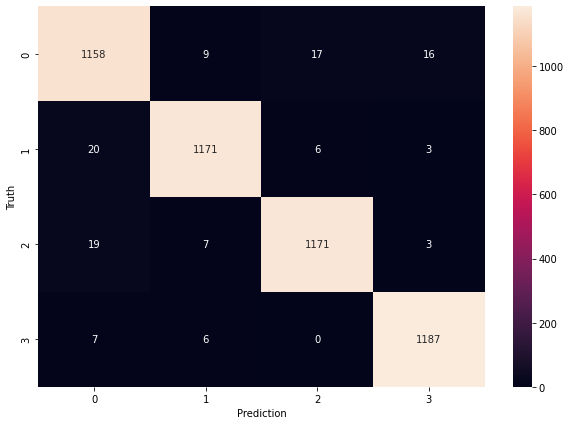

In [ ]:
from matplotlib import pyplot as plt
import seaborn as sn
plt.figure(figsize = (10,7))
sn.heatmap(cm, annot=True, fmt='d')
plt.xlabel('Prediction')
plt.ylabel('Truth')